In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
df = pd.read_excel("RunningTimeRecord.xlsx", sheet_name="Testing 2", skiprows=3)

df.head()

,Num Threads,Computational Time (sec),Computational Time (sec).1,Speedup,Computational Time (sec).2
0,1,1.981976,1.998806,0.99158,2.050615
1,4,1.981976,1.163114,1.704026,0.620855
2,8,1.981976,0.663606,2.986676,0.397514
3,16,1.981976,0.445718,4.446704,0.393962
4,32,1.981976,0.446779,4.436144,0.405892


In [29]:
df2 = df.iloc[0:6, 0:4].copy()

df2.rename(columns={"Num Threads": "num_threads",
                    "Computational Time (sec)": "serial_comp_time",
                    "Computational Time (sec).1": "parallel_comp_time",
                    "Speedup": "speedup"},
           inplace=True)

df2.reset_index(drop=True, inplace=True)

df2

,num_threads,serial_comp_time,parallel_comp_time,speedup
0,1,1.981976,1.998806,0.99158
1,4,1.981976,1.163114,1.704026
2,8,1.981976,0.663606,2.986676
3,16,1.981976,0.445718,4.446704
4,32,1.981976,0.446779,4.436144
5,64,1.981976,0.445172,4.452158


In [30]:
df3 = df.iloc[11:17, 0:4].copy()

df3.rename(columns={"Num Threads": "num_threads",
                    "Computational Time (sec)": "serial_comp_time",
                    "Computational Time (sec).1": "parallel_comp_time",
                    "Speedup": "speedup"},
           inplace=True)

df3.reset_index(drop=True, inplace=True)

df3

,num_threads,serial_comp_time,parallel_comp_time,speedup
0,1,1.909535,1.780315,1.072583
1,4,1.909535,0.912144,2.093458
2,8,1.909535,0.412225,4.632264
3,16,1.909535,0.248222,7.692852
4,32,1.909535,0.18618,10.256392
5,64,1.909535,0.175349,10.889911


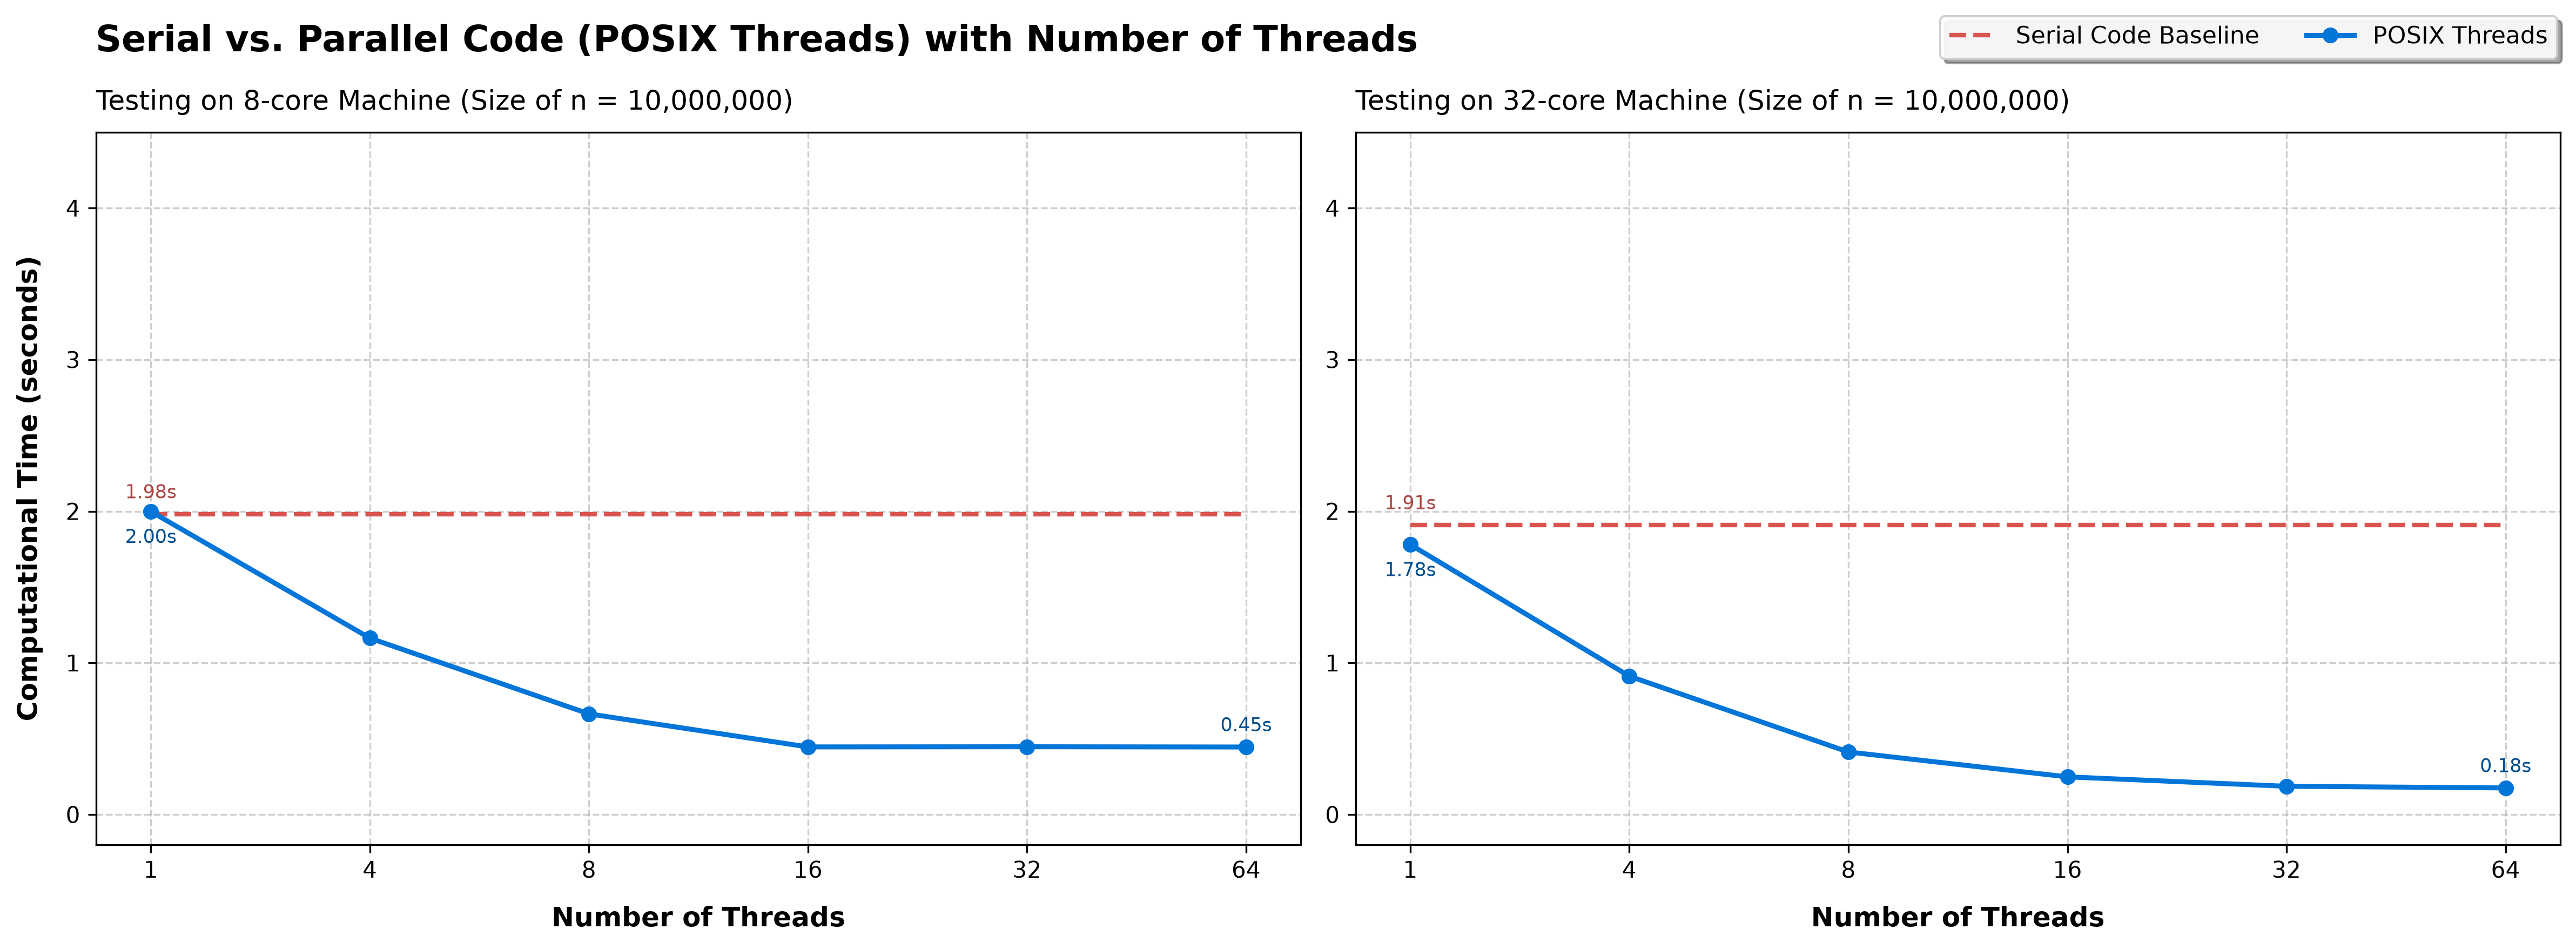

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# =========================
# 8-core graph
# =========================
ax = axes[0]

line1, = ax.plot(range(len(df2.num_threads)), df2.serial_comp_time,
                 linestyle='--', linewidth=2.0,
                 color='#D9534F', label='Serial Code Baseline')

line2, = ax.plot(range(len(df2.num_threads)), df2.parallel_comp_time,
                 marker='o', markersize=6, linewidth=2.2,
                 color='#0275D8', label='POSIX Threads')

ax.set_title("Testing on 8-core Machine (Size of n = 10,000,000)",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Number of Threads",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_ylabel("Computational Time (seconds)",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(range(len(df2.num_threads)))
ax.set_xticklabels(df2.num_threads, fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-0.2, 4.5)

# Annotations
ax.annotate(f"{df2.serial_comp_time.iloc[0]:.2f}s",
            (0, df2.serial_comp_time.iloc[0]),
            textcoords='offset points',
            xytext=(0, 7),
            ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df2.parallel_comp_time.iloc[0]:.2f}s",
            (0, df2.parallel_comp_time.iloc[0]),
            textcoords='offset points',
            xytext=(0, -14),
            ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df2.parallel_comp_time.iloc[-1]:.2f}s",
            (len(df2.num_threads) - 1, df2.parallel_comp_time.iloc[-1]),
            textcoords='offset points',
            xytext=(0, 7),
            ha='center',
            fontsize=8.5, color='#014C8C')


# =========================
# 32-core graph
# =========================
ax = axes[1]

# Serial Baseline
ax.plot(range(len(df3.num_threads)), df3.serial_comp_time,
        linestyle='--', linewidth=2.0,
        color='#D9534F')

# Parallel Code (POSIX Threads)
ax.plot(range(len(df3.num_threads)), df3.parallel_comp_time,
        marker='o', markersize=6, linewidth=2.2,
        color='#0275D8')

ax.set_title("Testing on 32-core Machine (Size of n = 10,000,000)",
             fontsize=12, loc='left', pad=10)

ax.set_xlabel("Number of Threads",
              fontsize=12, fontweight='semibold', labelpad=10)

ax.set_xticks(range(len(df3.num_threads)))
ax.set_xticklabels(df3.num_threads, fontsize=10)

ax.tick_params(axis='y', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-0.2, 4.5)

# Annotations
ax.annotate(f"{df3.serial_comp_time.iloc[0]:.2f}s",
            (0, df3.serial_comp_time.iloc[0]),
            textcoords='offset points',
            xytext=(0, 7),
            ha='center',
            fontsize=8.5, color='#A94442')

ax.annotate(f"{df3.parallel_comp_time.iloc[0]:.2f}s",
            (0, df3.parallel_comp_time.iloc[0]),
            textcoords='offset points',
            xytext=(0, -14),
            ha='center',
            fontsize=8.5, color='#014C8C')

ax.annotate(f"{df3.parallel_comp_time.iloc[-1]:.2f}s",
            (len(df3.num_threads) - 1, df3.parallel_comp_time.iloc[-1]),
            textcoords='offset points',
            xytext=(0, 7),
            ha='center',
            fontsize=8.5, color='#014C8C')


# =========================
# Overall title
# =========================
fig.suptitle(
    "Serial vs. Parallel Code (POSIX Threads) with Number of Threads",
    fontsize=16,
    fontweight='bold',
    x=0.04,
    y=0.96,
    ha='left'
)

# =========================
# Unified Global Legend
# =========================
fig.legend(
    handles=[line1, line2],
    labels=['Serial Code Baseline', 'POSIX Threads'],
    loc='upper right',
    bbox_to_anchor=(0.994, 0.98),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    framealpha=0.9,
    shadow=True
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("task2_graph2.png", dpi=300)
plt.show()